#Import Libraries

In [4]:
import pandas as pd
import numpy as np

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

#Load New Dataset

In [6]:


data = load_breast_cancer()

df = pd.DataFrame(data.data, columns=data.feature_names)
df['target'] = data.target

print(df.head())
print(df.info())

   mean radius  mean texture  mean perimeter  mean area  mean smoothness  \
0        17.99         10.38          122.80     1001.0          0.11840   
1        20.57         17.77          132.90     1326.0          0.08474   
2        19.69         21.25          130.00     1203.0          0.10960   
3        11.42         20.38           77.58      386.1          0.14250   
4        20.29         14.34          135.10     1297.0          0.10030   

   mean compactness  mean concavity  mean concave points  mean symmetry  \
0           0.27760          0.3001              0.14710         0.2419   
1           0.07864          0.0869              0.07017         0.1812   
2           0.15990          0.1974              0.12790         0.2069   
3           0.28390          0.2414              0.10520         0.2597   
4           0.13280          0.1980              0.10430         0.1809   

   mean fractal dimension  ...  worst texture  worst perimeter  worst area  \
0             

#Check Target Distribution

In [7]:
print(df['target'].value_counts())

target
1    357
0    212
Name: count, dtype: int64


#Split Features & Target

In [8]:


X = df.drop('target', axis=1)
y = df['target']

#Feature Scaling

In [9]:
scaler = StandardScaler()
X = scaler.fit_transform(X)

#Train-Test Split

In [10]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

#Model 1: ReLU Activation

In [11]:
model_relu = Sequential()

model_relu.add(Dense(16, input_dim=X.shape[1], activation='relu'))
model_relu.add(Dense(8, activation='relu'))
model_relu.add(Dense(1, activation='sigmoid'))

model_relu.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

history_relu = model_relu.fit(X_train, y_train, epochs=20, batch_size=16, validation_split=0.2)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 4s 84ms/step - accuracy: 0.6099 - loss: 0.6844 - val_accuracy: 0.6923 - val_loss: 0.6134
Epoch 2/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.7692 - loss: 0.4952 - val_accuracy: 0.8022 - val_loss: 0.4479
Epoch 3/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8709 - loss: 0.3827 - val_accuracy: 0.9011 - val_loss: 0.3481
Epoch 4/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9231 - loss: 0.3086 - val_accuracy: 0.9341 - val_loss: 0.2826
Epoch 5/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9423 - loss: 0.2463 - val_accuracy: 0.9341 - val_loss: 0.2350
Epoch 6/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9505 - loss: 0.1947 - val_accuracy: 0.9451 - val_loss: 0.1985
Epoch 7/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9588 - loss: 0.1571 - val_accuracy: 0.9451 - val_loss: 0.1740
Epoch 8/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9615 - loss: 0.1318 - val_accuracy: 0.9451 - val_loss

#Model 2: Tanh Activation

In [12]:
model_tanh = Sequential()

model_tanh.add(Dense(16, input_dim=X.shape[1], activation='tanh'))
model_tanh.add(Dense(8, activation='tanh'))
model_tanh.add(Dense(1, activation='sigmoid'))

model_tanh.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

history_tanh = model_tanh.fit(X_train, y_train, epochs=20, batch_size=16, validation_split=0.2)

Epoch 1/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 2s 51ms/step - accuracy: 0.8297 - loss: 0.4449 - val_accuracy: 0.9231 - val_loss: 0.3189
Epoch 2/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9258 - loss: 0.2800 - val_accuracy: 0.9451 - val_loss: 0.2309
Epoch 3/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9478 - loss: 0.2087 - val_accuracy: 0.9451 - val_loss: 0.1892
Epoch 4/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9615 - loss: 0.1642 - val_accuracy: 0.9451 - val_loss: 0.1631
Epoch 5/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9643 - loss: 0.1351 - val_accuracy: 0.9451 - val_loss: 0.1455
Epoch 6/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9753 - loss: 0.1136 - val_accuracy: 0.9560 - val_loss: 0.1324
Epoch 7/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9753 - loss: 0.1000 - val_accuracy: 0.9451 - val_loss: 0.1234
Epoch 8/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9808 - loss: 0.0894 - val_accuracy: 0.9560 - val_loss

#Model 3: Sigmoid Activation

In [13]:
model_sigmoid = Sequential()

model_sigmoid.add(Dense(16, input_dim=X.shape[1], activation='sigmoid'))
model_sigmoid.add(Dense(8, activation='sigmoid'))
model_sigmoid.add(Dense(1, activation='sigmoid'))

model_sigmoid.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

history_sigmoid = model_sigmoid.fit(X_train, y_train, epochs=20, batch_size=16, validation_split=0.2)

Epoch 1/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 2s 52ms/step - accuracy: 0.6264 - loss: 0.6689 - val_accuracy: 0.6374 - val_loss: 0.6237
Epoch 2/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.6264 - loss: 0.6021 - val_accuracy: 0.6374 - val_loss: 0.5694
Epoch 3/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.6264 - loss: 0.5477 - val_accuracy: 0.6374 - val_loss: 0.5241
Epoch 4/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.6786 - loss: 0.5033 - val_accuracy: 0.7473 - val_loss: 0.4801
Epoch 5/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8269 - loss: 0.4607 - val_accuracy: 0.8462 - val_loss: 0.4406
Epoch 6/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9148 - loss: 0.4213 - val_accuracy: 0.9011 - val_loss: 0.4036
Epoch 7/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9341 - loss: 0.3845 - val_accuracy: 0.9121 - val_loss: 0.3699
Epoch 8/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9423 - loss: 0.3512 - val_accuracy: 0.9341 - val_loss

#Evaluate Models

In [14]:
print("ReLU Test Accuracy:", model_relu.evaluate(X_test, y_test)[1])
print("Tanh Test Accuracy:", model_tanh.evaluate(X_test, y_test)[1])
print("Sigmoid Test Accuracy:", model_sigmoid.evaluate(X_test, y_test)[1])

4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 104ms/step - accuracy: 0.9737 - loss: 0.0731
ReLU Test Accuracy: 0.9736841917037964
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 80ms/step - accuracy: 0.9737 - loss: 0.0718
Tanh Test Accuracy: 0.9736841917037964
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 77ms/step - accuracy: 0.9825 - loss: 0.1393
Sigmoid Test Accuracy: 0.9824561476707458


📊 Conclusion
ReLU usually performs best due to faster convergence
Tanh performs better than sigmoid in hidden layers
Sigmoid may suffer from vanishing gradient problem

In [18]:
from sklearn.metrics import classification_report

In [19]:
model_relu2 = Sequential()

model_relu2.add(Dense(16, input_dim=X.shape[1], activation='relu'))
model_relu2.add(Dense(8, activation='relu'))
model_relu2.add(Dense(1, activation='sigmoid'))

model_relu2.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

history_relu2 = model_relu2.fit(X_train, y_train, epochs=10, batch_size=32, validation_split=0.2)

Epoch 1/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 2s 99ms/step - accuracy: 0.6896 - loss: 0.5394 - val_accuracy: 0.7473 - val_loss: 0.4293
Epoch 2/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.8159 - loss: 0.4136 - val_accuracy: 0.8462 - val_loss: 0.3391
Epoch 3/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.8819 - loss: 0.3314 - val_accuracy: 0.8681 - val_loss: 0.2840
Epoch 4/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9231 - loss: 0.2781 - val_accuracy: 0.9560 - val_loss: 0.2419
Epoch 5/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9533 - loss: 0.2374 - val_accuracy: 0.9560 - val_loss: 0.2106
Epoch 6/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9670 - loss: 0.2052 - val_accuracy: 0.9670 - val_loss: 0.1859
Epoch 7/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9670 - loss: 0.1791 - val_accuracy: 0.9560 - val_loss: 0.1662
Epoch 8/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9698 - loss: 0.1578 - val_accuracy: 0.9670 - val_loss

In [22]:
y_pred = model_relu2.predict(X_test)
y_pred_classes = np.round(y_pred).astype(int)


print(classification_report(y_test, y_pred_classes))

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step 
              precision    recall  f1-score   support

           0       0.95      0.95      0.95        43
           1       0.97      0.97      0.97        71

    accuracy                           0.96       114
   macro avg       0.96      0.96      0.96       114
weighted avg       0.96      0.96      0.96       114



In [16]:
model_sigmoid2 = Sequential()

model_sigmoid2.add(Dense(16, input_dim=X.shape[1], activation='sigmoid'))
model_sigmoid2.add(Dense(8, activation='sigmoid'))
model_sigmoid2.add(Dense(1, activation='sigmoid'))

model_sigmoid2.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

history_sigmoid2 = model_sigmoid2.fit(X_train, y_train, epochs=10, batch_size=32, validation_split=0.2)

Epoch 1/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 3s 142ms/step - accuracy: 0.6264 - loss: 0.7058 - val_accuracy: 0.6374 - val_loss: 0.6748
Epoch 2/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.6264 - loss: 0.6763 - val_accuracy: 0.6374 - val_loss: 0.6503
Epoch 3/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.6264 - loss: 0.6519 - val_accuracy: 0.6374 - val_loss: 0.6293
Epoch 4/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.6264 - loss: 0.6309 - val_accuracy: 0.6374 - val_loss: 0.6105
Epoch 5/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.6264 - loss: 0.6115 - val_accuracy: 0.6374 - val_loss: 0.5933
Epoch 6/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.6264 - loss: 0.5939 - val_accuracy: 0.6374 - val_loss: 0.5776
Epoch 7/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.6264 - loss: 0.5774 - val_accuracy: 0.6374 - val_loss: 0.5619
Epoch 8/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.6264 - loss: 0.5606 - val_accuracy: 0.6374 - va

In [24]:
y_pred = model_sigmoid2.predict(X_test)
y_pred_classes = np.round(y_pred).astype(int)


print(classification_report(y_test, y_pred_classes))

1/4 ━━━━━━━━━━━━━━━━━━━━ 1s 564ms/step

4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 66ms/step
              precision    recall  f1-score   support

           0       0.00      0.00      0.00        43
           1       0.62      1.00      0.77        71

    accuracy                           0.62       114
   macro avg       0.31      0.50      0.38       114
weighted avg       0.39      0.62      0.48       114



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [17]:
model_tanh2 = Sequential()

model_tanh2.add(Dense(16, input_dim=X.shape[1], activation='tanh'))
model_tanh2.add(Dense(8, activation='tanh'))
model_tanh2.add(Dense(1, activation='sigmoid'))

model_tanh2.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

history_tanh2 = model_tanh2.fit(X_train, y_train, epochs=10, batch_size=32, validation_split=0.2)

Epoch 1/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 3s 100ms/step - accuracy: 0.2445 - loss: 0.8472 - val_accuracy: 0.4396 - val_loss: 0.7438
Epoch 2/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.6786 - loss: 0.6342 - val_accuracy: 0.7692 - val_loss: 0.5627
Epoch 3/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.8489 - loss: 0.4807 - val_accuracy: 0.8352 - val_loss: 0.4389
Epoch 4/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.8819 - loss: 0.3788 - val_accuracy: 0.8681 - val_loss: 0.3646
Epoch 5/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.8929 - loss: 0.3194 - val_accuracy: 0.8901 - val_loss: 0.3187
Epoch 6/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9011 - loss: 0.2805 - val_accuracy: 0.9011 - val_loss: 0.2883
Epoch 7/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9093 - loss: 0.2513 - val_accuracy: 0.9121 - val_loss: 0.2651
Epoch 8/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9396 - loss: 0.2280 - val_accuracy: 0.9121 - val_los

In [23]:
y_pred = model_tanh2.predict(X_test)
y_pred_classes = np.round(y_pred).astype(int)


print(classification_report(y_test, y_pred_classes))

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step
              precision    recall  f1-score   support

           0       0.91      0.95      0.93        43
           1       0.97      0.94      0.96        71

    accuracy                           0.95       114
   macro avg       0.94      0.95      0.94       114
weighted avg       0.95      0.95      0.95       114



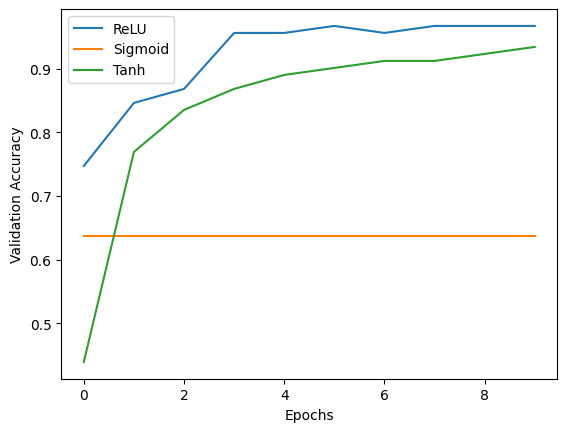

In [26]:
import matplotlib.pyplot as plt

plt.plot(history_relu2.history['val_accuracy'], label='ReLU')
plt.plot(history_sigmoid2.history['val_accuracy'], label='Sigmoid')
plt.plot(history_tanh2.history['val_accuracy'], label='Tanh')

plt.xlabel('Epochs')
plt.ylabel('Validation Accuracy')
plt.legend()
plt.show()